In [16]:
# EDA Notebook: Climate Change & Food Security (Nigeria)
# This notebook curates public national-level datasets and performs basic exploratory analysis.

import datetime as dt
import importlib.util
import json
import sys
from pathlib import Path


def ensure_packages_installed() -> None:
    import subprocess

    required = {
        "pandas": "pandas",
        "numpy": "numpy",
        "requests": "requests",
        "matplotlib": "matplotlib",
        "seaborn": "seaborn",
        "sklearn": "scikit-learn",
    }

    missing = [pip_name for module, pip_name in required.items() if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])


ensure_packages_installed()

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns


REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
FIG_DIR = PROCESSED_DIR / "figures"

for p in [RAW_DIR, PROCESSED_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Nigeria centroid (approx.) for point-based climate series.
NIGERIA_LAT = 9.0820
NIGERIA_LON = 8.6753


def http_get_json(url: str, params: dict | None = None, timeout_s: int = 60) -> dict:
    resp = requests.get(url, params=params, timeout=timeout_s)
    if resp.status_code >= 400:
        snippet = (resp.text or "").strip()[:2000]
        raise RuntimeError(
            f"HTTP {resp.status_code} for {resp.url}\n"
            f"Response (first 2000 chars):\n{snippet}"
        )
    return resp.json()


def _normalize_yyyymm(value: str) -> str:
    s = str(value).strip()
    if len(s) == 5 and s[:4].isdigit() and s[4:].isdigit():
        return s[:4] + s[4:].zfill(2)
    if len(s) == 6 and s.isdigit():
        return s
    digits = "".join(ch for ch in s if ch.isdigit())
    return digits.zfill(6)


def fetch_nasa_power_monthly(lat: float, lon: float, start_year: int, end_year: int) -> pd.DataFrame:
    """Fetch monthly climate series from NASA POWER for a point."""
    url = "https://power.larc.nasa.gov/api/temporal/monthly/point"

    candidate_ranges = [
        (f"{start_year}0101", f"{end_year}1231"),  # YYYYMMDD
        (f"{start_year}01", f"{end_year}12"),      # YYYYMM
        (str(start_year), str(end_year)),            # YYYY
    ]

    last_error: Exception | None = None
    payload = None

    for start, end in candidate_ranges:
        params = {
            "community": "AG",
            "parameters": "T2M,PRECTOT",
            "latitude": lat,
            "longitude": lon,
            "start": start,
            "end": end,
            "format": "JSON",
        }
        try:
            payload = http_get_json(url, params=params)
            break
        except Exception as e:
            last_error = e

    if payload is None:
        raise RuntimeError(f"NASA POWER request failed for all date formats. Last error: {last_error}")

    param = payload["properties"]["parameter"]

    precip_key = None
    for k in ["PRECTOT", "PRECTOTCORR"]:
        if k in param:
            precip_key = k
            break

    if precip_key is None:
        available = ", ".join(sorted(param.keys()))
        raise KeyError(f"No precipitation variable found. Available keys: {available}")

    t2m = pd.Series(param["T2M"], name="t2m_c")
    pr = pd.Series(param[precip_key], name="precip_mm_day")

    df = pd.concat([t2m, pr], axis=1).reset_index(names="yyyymm")
    df["yyyymm"] = df["yyyymm"].map(_normalize_yyyymm)

    # POWER sometimes includes annual summary values as "month 13" (YYYY13). Keep months 01–12 only.
    df["month"] = df["yyyymm"].str[4:6].astype(int)
    df = df[df["month"].between(1, 12)].copy()

    df["date"] = pd.to_datetime(df["yyyymm"] + "01", format="%Y%m%d", errors="coerce")
    if df["date"].isna().any():
        bad = df.loc[df["date"].isna(), "yyyymm"].head(10).tolist()
        raise ValueError(f"Could not parse some POWER month keys (sample): {bad}")

    days_in_month = df["date"].dt.days_in_month
    df["precip_mm_month"] = df["precip_mm_day"].astype(float) * days_in_month

    df = df[["date", "t2m_c", "precip_mm_day", "precip_mm_month"]].sort_values("date")

    meta = {
        "source": "NASA POWER temporal/monthly/point",
        "lat": lat,
        "lon": lon,
        "start_year": start_year,
        "end_year": end_year,
        "downloaded_utc": dt.datetime.utcnow().isoformat() + "Z",
        "api_url": payload.get("header", {}).get("api") or url,
        "title": payload.get("header", {}).get("title"),
        "precip_variable_used": precip_key,
    }
    meta_path = RAW_DIR / "nasa_power_nigeria_point_metadata.json"
    meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    return df


def fetch_worldbank_indicator(country: str, indicator_code: str) -> pd.DataFrame:
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator_code}"
    params = {"format": "json", "per_page": 20000}
    payload = http_get_json(url, params=params)

    if not isinstance(payload, list) or len(payload) < 2:
        raise ValueError(f"Unexpected World Bank response for {indicator_code}")

    rows = payload[1] or []
    df = pd.DataFrame(
        {
            "year": [int(r["date"]) for r in rows if r.get("date") is not None],
            "value": [r.get("value") for r in rows],
        }
    )

    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["year"]).drop_duplicates(subset=["year"]).sort_values("year")
    return df


def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


print("Repo root:", REPO_ROOT)
print("Raw dir:", RAW_DIR)
print("Processed dir:", PROCESSED_DIR)
print("Figures dir:", FIG_DIR)


Repo root: /workspaces/world_ai
Raw dir: /workspaces/world_ai/data/raw
Processed dir: /workspaces/world_ai/data/processed
Figures dir: /workspaces/world_ai/data/processed/figures


In [17]:
# Cell 2: Download/curate raw datasets

current_year = dt.date.today().year
# Use last completed year for stability (avoid partial current-year data)
END_YEAR = current_year - 1
START_YEAR = 1981

# 2.1 NASA POWER (monthly climate at Nigeria centroid)
climate_monthly_path = RAW_DIR / "nasa_power_nigeria_monthly.csv"
try:
    climate_monthly = fetch_nasa_power_monthly(NIGERIA_LAT, NIGERIA_LON, START_YEAR, END_YEAR)
    save_csv(climate_monthly, climate_monthly_path)
    print("Saved:", climate_monthly_path, "rows=", len(climate_monthly))
except Exception as e:
    print("NASA POWER download failed; continuing with WDI only.")
    print(e)

# 2.2 World Bank WDI indicators (annual)
# Note: availability varies; the notebook will skip series that are unavailable.
INDICATORS = {
    "AG.YLD.CREL.KG": "cereal_yield_kg_per_ha",
    "AG.PRD.FOOD.XD": "food_production_index",
    "NV.AGR.TOTL.ZS": "ag_value_added_pct_gdp",
    "SN.ITK.DEFC.ZS": "prevalence_of_undernourishment_pct",
    # Commonly-used food security proxies (may be missing for some years)
    "SN.ITK.MSFI.ZS": "moderate_or_severe_food_insecurity_pct",
}

wdi_frames = []
failed = []
for code, name in INDICATORS.items():
    try:
        df = fetch_worldbank_indicator("NGA", code)
        df = df.rename(columns={"value": name})
        out_path = RAW_DIR / f"wdi_{code.replace('.', '_')}.csv"
        save_csv(df, out_path)
        print("Saved:", out_path, "rows=", len(df))
        wdi_frames.append(df)
    except Exception as e:
        failed.append((code, str(e)))

if failed:
    print("\nIndicators that could not be downloaded (this can be normal):")
    for code, err in failed:
        print("-", code, "=>", err)

print("\nDownloaded indicator series:", len(wdi_frames))


/tmp/ipykernel_21744/3580723504.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "downloaded_utc": dt.datetime.utcnow().isoformat() + "Z",


Saved: /workspaces/world_ai/data/raw/nasa_power_nigeria_monthly.csv rows= 540
Saved: /workspaces/world_ai/data/raw/wdi_AG_YLD_CREL_KG.csv rows= 66
Saved: /workspaces/world_ai/data/raw/wdi_AG_PRD_FOOD_XD.csv rows= 66
Saved: /workspaces/world_ai/data/raw/wdi_NV_AGR_TOTL_ZS.csv rows= 66
Saved: /workspaces/world_ai/data/raw/wdi_SN_ITK_DEFC_ZS.csv rows= 66
Saved: /workspaces/world_ai/data/raw/wdi_SN_ITK_MSFI_ZS.csv rows= 66

Downloaded indicator series: 5


In [18]:
# Cell 3: Build analysis-ready (annual) dataset

climate_monthly = pd.read_csv(RAW_DIR / "nasa_power_nigeria_monthly.csv", parse_dates=["date"])

climate_monthly["year"] = climate_monthly["date"].dt.year
climate_annual = climate_monthly.groupby("year", as_index=False).agg(
    t2m_c_mean=("t2m_c", "mean"),
    precip_mm_month_sum=("precip_mm_month", "sum"),
)

# Load all WDI raw files and merge by year
wdi_files = sorted(RAW_DIR.glob("wdi_*.csv"))
wdi_annual = None

for f in wdi_files:
    df = pd.read_csv(f)
    if "year" not in df.columns:
        continue

    value_cols = [c for c in df.columns if c != "year"]
    if not value_cols:
        continue

    df = df[["year"] + value_cols]
    wdi_annual = df if wdi_annual is None else wdi_annual.merge(df, on="year", how="outer")

if wdi_annual is None:
    raise RuntimeError("No WDI datasets found in data/raw. Run Cell 2 first.")

annual = climate_annual.merge(wdi_annual, on="year", how="outer").sort_values("year")

out_annual = PROCESSED_DIR / "nigeria_climate_foodsecurity_annual.csv"
out_monthly = PROCESSED_DIR / "nigeria_climate_monthly.csv"

save_csv(annual, out_annual)
save_csv(climate_monthly, out_monthly)

print("Saved:", out_annual, "rows=", len(annual), "cols=", annual.shape[1])
print("Saved:", out_monthly, "rows=", len(climate_monthly))

annual.tail(10)

Saved: /workspaces/world_ai/data/processed/nigeria_climate_foodsecurity_annual.csv rows= 66 cols= 8
Saved: /workspaces/world_ai/data/processed/nigeria_climate_monthly.csv rows= 540


,year,t2m_c_mean,precip_mm_month_sum,food_production_index,cereal_yield_kg_per_ha,ag_value_added_pct_gdp,prevalence_of_undernourishment_pct,moderate_or_severe_food_insecurity_pct
56,2016,25.246667,1390.21,106.78,1596.9,20.983110,10.8,38.7
57,2017,25.573333,920.58,109.08,1506.1,20.846571,11.5,42.8
58,2018,25.667500,904.68,114.06,1549.3,21.203774,12.1,47.1
59,2019,25.707500,1116.37,109.77,1629.7,25.734931,14.3,53.5
60,2020,25.074167,1162.18,112.64,1619.9,28.345420,15.8,62.9
61,2021,25.285000,1506.21,117.33,1621.9,29.388278,17.6,69.7
62,2022,24.282500,1714.71,119.85,1659.5,28.551552,18.7,73.9
63,2023,26.236667,693.71,NaN,1548.6,27.718291,19.9,74.8
64,2024,26.068333,1151.47,NaN,1558.0,25.873334,NaN,NaN
65,2025,26.860000,776.40,NaN,NaN,NaN,NaN,NaN


Year range: 1960 - 2025
Saved: /workspaces/world_ai/data/processed/missingness_summary.csv
Saved: /workspaces/world_ai/data/processed/annual_describe.csv


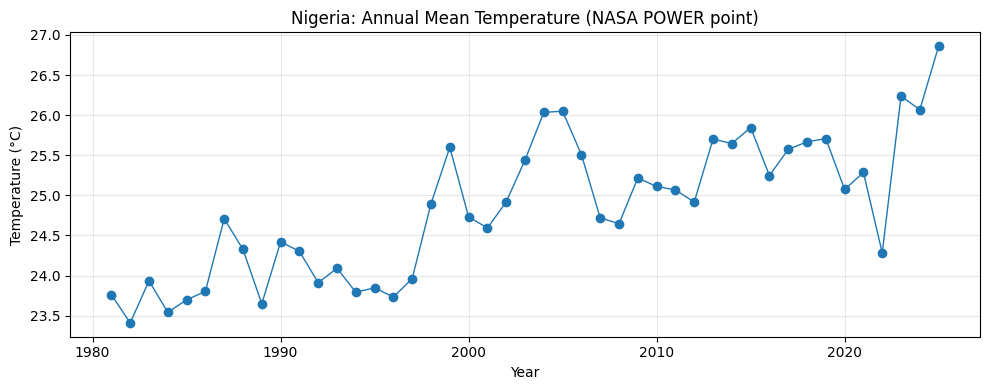

Saved: /workspaces/world_ai/data/processed/figures/temp_timeseries.png
Saved: /workspaces/world_ai/data/processed/figures/temp_timeseries.svg


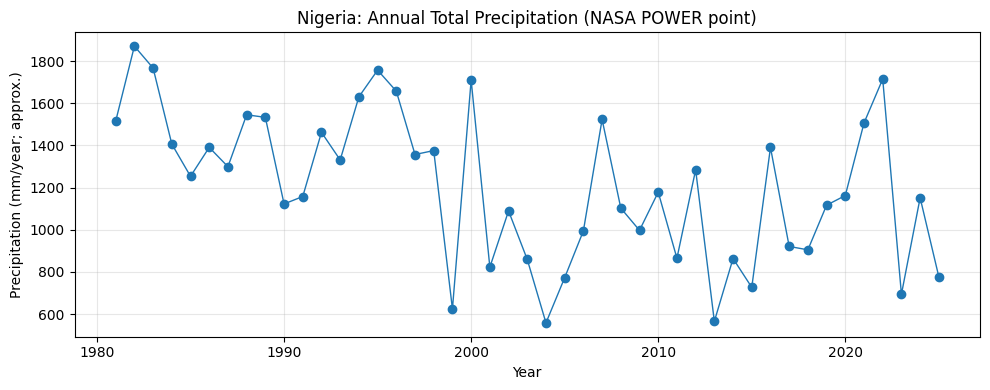

Saved: /workspaces/world_ai/data/processed/figures/precip_timeseries.png
Saved: /workspaces/world_ai/data/processed/figures/precip_timeseries.svg
Saved: /workspaces/world_ai/data/processed/correlation_matrix.csv


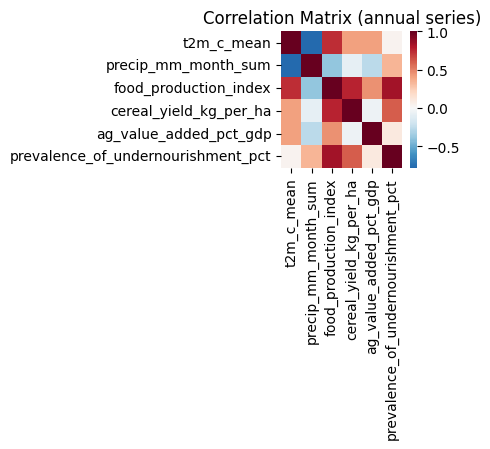

Saved: /workspaces/world_ai/data/processed/figures/correlation_heatmap.png
Saved: /workspaces/world_ai/data/processed/figures/correlation_heatmap.svg


,missing_%
moderate_or_severe_food_insecurity_pct,86.4
prevalence_of_undernourishment_pct,65.2
ag_value_added_pct_gdp,33.3
t2m_c_mean,31.8
precip_mm_month_sum,31.8
food_production_index,6.1
cereal_yield_kg_per_ha,3.0
year,0.0


In [21]:
# Cell 4: EDA summaries and plots

annual = pd.read_csv(PROCESSED_DIR / "nigeria_climate_foodsecurity_annual.csv")

print("Year range:", annual["year"].min(), "-", annual["year"].max())

# Ensure figures folder exists
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Missingness summary
missing = (
    annual.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .to_frame("missing_%")
)
missing_path = PROCESSED_DIR / "missingness_summary.csv"
save_csv(missing.reset_index(names="column"), missing_path)
print("Saved:", missing_path)

# Basic describe for numeric columns
numeric_cols = [c for c in annual.columns if c != "year"]
desc = annual[numeric_cols].describe().T

desc_path = PROCESSED_DIR / "annual_describe.csv"
save_csv(desc.reset_index(names="variable"), desc_path)
print("Saved:", desc_path)

# Time series plots for climate
plt.figure(figsize=(10, 4))
plt.plot(annual["year"], annual["t2m_c_mean"], marker="o", linewidth=1)
plt.title("Nigeria: Annual Mean Temperature (NASA POWER point)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
temp_png = FIG_DIR / "temp_timeseries.png"
temp_svg = FIG_DIR / "temp_timeseries.svg"
plt.savefig(temp_png, dpi=150)
plt.savefig(temp_svg)
plt.show()
print("Saved:", temp_png)
print("Saved:", temp_svg)

plt.figure(figsize=(10, 4))
plt.plot(annual["year"], annual["precip_mm_month_sum"], marker="o", linewidth=1)
plt.title("Nigeria: Annual Total Precipitation (NASA POWER point)")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm/year; approx.)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
precip_png = FIG_DIR / "precip_timeseries.png"
precip_svg = FIG_DIR / "precip_timeseries.svg"
plt.savefig(precip_png, dpi=150)
plt.savefig(precip_svg)
plt.show()
print("Saved:", precip_png)
print("Saved:", precip_svg)

# Correlation heatmap (numeric only)
num = annual.drop(columns=["year"]).select_dtypes(include=["number"]).copy()
num = num.loc[:, num.notna().sum() >= 10]

if num.shape[1] >= 2:
    corr = num.corr(numeric_only=True)
    corr_path = PROCESSED_DIR / "correlation_matrix.csv"
    corr.to_csv(corr_path)
    print("Saved:", corr_path)

    plt.figure(figsize=(min(12, 1 + 0.6 * corr.shape[1]), min(10, 1 + 0.6 * corr.shape[0])))
    sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False)
    plt.title("Correlation Matrix (annual series)")
    plt.tight_layout()
    heat_png = FIG_DIR / "correlation_heatmap.png"
    heat_svg = FIG_DIR / "correlation_heatmap.svg"
    plt.savefig(heat_png, dpi=150)
    plt.savefig(heat_svg)
    plt.show()
    print("Saved:", heat_png)
    print("Saved:", heat_svg)
else:
    print("Not enough numeric columns for correlation analysis.")

missing.head(15)

In [20]:
# Cell 5: Simple benchmarking baselines (optional)
# Goal: provide quick baseline predictive relationships you can reference as “benchmarks”.

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge

annual = pd.read_csv(PROCESSED_DIR / "nigeria_climate_foodsecurity_annual.csv")

feature_cols = ["t2m_c_mean", "precip_mm_month_sum"]

candidate_targets = [
    "cereal_yield_kg_per_ha",
    "food_production_index",
    "prevalence_of_undernourishment_pct",
    "moderate_or_severe_food_insecurity_pct",
]

available_targets = [t for t in candidate_targets if t in annual.columns]

results = []

for target in available_targets:
    df = annual[["year"] + feature_cols + [target]].dropna()
    if len(df) < 15:
        continue

    X = df[feature_cols].values
    y = df[target].values

    tscv = TimeSeriesSplit(n_splits=5)

    for model_name, model in [
        ("linear", LinearRegression()),
        ("ridge", Ridge(alpha=1.0)),
    ]:
        fold_scores = []
        for train_idx, test_idx in tscv.split(X):
            model.fit(X[train_idx], y[train_idx])
            pred = model.predict(X[test_idx])
            fold_scores.append(r2_score(y[test_idx], pred))

        results.append(
            {
                "target": target,
                "model": model_name,
                "n_obs": len(df),
                "cv_r2_mean": float(np.mean(fold_scores)),
                "cv_r2_std": float(np.std(fold_scores)),
            }
        )

bench = pd.DataFrame(results).sort_values(["target", "model"]) if results else pd.DataFrame()

bench_path = PROCESSED_DIR / "benchmark_baselines.csv"
if len(bench):
    save_csv(bench, bench_path)
    print("Saved:", bench_path)
    display(bench)
else:
    print(
        "No benchmark results computed (targets missing or too few observations). "
        "This is normal if series are sparse."
    )


Saved: /workspaces/world_ai/data/processed/benchmark_baselines.csv


,target,model,n_obs,cv_r2_mean,cv_r2_std
0,cereal_yield_kg_per_ha,linear,44,-17.332792,10.929344
1,cereal_yield_kg_per_ha,ridge,44,-17.144527,10.049590
2,food_production_index,linear,42,-27.339538,28.948741
3,food_production_index,ridge,42,-30.417727,32.212248
4,prevalence_of_undernourishment_pct,linear,23,-30.193137,27.464370
5,prevalence_of_undernourishment_pct,ridge,23,-30.686605,27.790409


In [24]:
# Cell 6: Build draft review paper as DOCX (with EDA tables/figures)

import datetime as dt
import importlib
import sys
from importlib import metadata
from pathlib import Path

import numpy as np
import pandas as pd


def ensure_python_docx_installed() -> None:
    """Ensure the `python-docx` distribution is installed."""

    try:
        metadata.version("python-docx")
    except metadata.PackageNotFoundError:
        import subprocess

        subprocess.check_call([sys.executable, "-m", "pip", "install", "python-docx"])


ensure_python_docx_installed()

# Force-import python-docx even though the repo contains a local `docx/` folder for outputs.
# 1) Clear any previously imported shadowing modules.
for mod_name in list(sys.modules.keys()):
    if mod_name == "docx" or mod_name.startswith("docx."):
        sys.modules.pop(mod_name, None)

# 2) Prepend the site-packages root where python-docx is installed.
_dist = metadata.distribution("python-docx")
_site_root = str(Path(_dist.locate_file("")).resolve())
if _site_root not in sys.path:
    sys.path.insert(0, _site_root)

# 3) Import from the installed distribution.
docx_mod = importlib.import_module("docx")
shared_mod = importlib.import_module("docx.shared")
Document = getattr(docx_mod, "Document")
Inches = getattr(shared_mod, "Inches")


def add_df_table(document, df: pd.DataFrame, title: str) -> None:
    document.add_heading(title, level=2)
    table = document.add_table(rows=1, cols=len(df.columns))
    table.style = "Table Grid"
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(df.columns):
        hdr_cells[i].text = str(col)

    for _, row in df.iterrows():
        row_cells = table.add_row().cells
        for i, col in enumerate(df.columns):
            val = row[col]
            row_cells[i].text = "" if pd.isna(val) else str(val)


repo_root = Path.cwd()
processed_dir = repo_root / "data" / "processed"
fig_dir = processed_dir / "figures"
docx_dir = repo_root / "docx"
docx_dir.mkdir(parents=True, exist_ok=True)

annual_path = processed_dir / "nigeria_climate_foodsecurity_annual.csv"
missing_path = processed_dir / "missingness_summary.csv"
bench_path = processed_dir / "benchmark_baselines.csv"

# Load analysis outputs
annual = pd.read_csv(annual_path)
missing = pd.read_csv(missing_path)
bench = pd.read_csv(bench_path) if bench_path.exists() else pd.DataFrame()

# Simple benchmark stats for narrative
annual_climate = annual[["year", "t2m_c_mean", "precip_mm_month_sum"]].dropna()

if len(annual_climate) >= 10:
    x = annual_climate["year"].values
    y = annual_climate["t2m_c_mean"].values
    slope = float(np.polyfit(x, y, 1)[0])  # °C per year
    temp_change = slope * (annual_climate["year"].max() - annual_climate["year"].min())
    precip_std = float(annual_climate["precip_mm_month_sum"].std())
else:
    slope = float("nan")
    temp_change = float("nan")
    precip_std = float("nan")

out_docx = docx_dir / "Climate_Change_Food_Security_Nigeria_Review_Draft.docx"

# --- Build manuscript ---
doc = Document()

# Title
doc.add_heading(
    "The Impact of Climate Change on Food Security in Nigeria: A Review of Empirical and Theoretical Evidence",
    level=0,
)

doc.add_paragraph("Draft review paper (journal-article format).")
doc.add_paragraph("Author(s): [Your Name(s)]")
doc.add_paragraph("Affiliation(s): [Your Department/Institution]")
doc.add_paragraph("Date: " + dt.date.today().isoformat())

# Abstract
doc.add_heading("Abstract", level=1)
abstract = (
    "Climate change poses escalating risks to food security in Nigeria through interacting pathways affecting "
    "agricultural production, food prices and incomes, nutrition and health, and the stability of food systems. "
    "This review synthesizes empirical and theoretical evidence on climate–food security linkages in Nigeria and "
    "summarizes policy-relevant adaptation options reported in recent literature. To complement the evidence synthesis, "
    "we provide a lightweight benchmarking analysis using public national-level datasets: monthly temperature and precipitation "
    "from NASA POWER and annual food/agriculture indicators from the World Bank World Development Indicators. "
)
if not np.isnan(slope):
    abstract += (
        f"The benchmarking analysis indicates a positive long-run trend in annual mean temperature of approximately {slope:.3f} °C/year "
        f"(≈{temp_change:.2f} °C over the observed period) and substantial interannual variability in precipitation "
        f"(standard deviation ≈{precip_std:.0f} mm/year). "
    )
abstract += (
    "Correlation patterns and simple time-series cross-validated baselines illustrate that climate variables alone explain only a limited share "
    "of variation in national food security proxies, underscoring the importance of socioeconomic mediators and adaptation capacity. "
    "We conclude by highlighting key mechanisms, vulnerable populations and regions, and research gaps for more causal and subnationally resolved evidence."
)

doc.add_paragraph(abstract)

# Keywords
doc.add_heading("Keywords", level=1)
doc.add_paragraph(
    "Nigeria; climate change; food security; agriculture; rainfall variability; temperature; adaptation; vulnerability; benchmarking"
)

# 1. Introduction
doc.add_heading("1. Introduction", level=1)
doc.add_paragraph(
    "Nigeria faces persistent food security challenges shaped by demographic pressures, macroeconomic conditions, market integration, "
    "infrastructure constraints, and exposure to climate hazards such as droughts and floods. Climate change can affect food security through "
    "direct biophysical impacts on crop and livestock productivity and through indirect pathways including prices, incomes, health burdens, and "
    "conflict and displacement. A synthesis that combines empirical evidence with theory-based pathway framing can support clearer policy prioritization "
    "and identify evidence gaps."
)

doc.add_paragraph(
    "This paper has two contributions. First, it provides a structured synthesis of empirical and theoretical evidence on climate change and food security in Nigeria. "
    "Second, it presents a transparent, reproducible benchmarking analysis using public national-level datasets to summarize climate trends and their association with widely used food and agriculture indicators."
)

# 2. Conceptual framework
doc.add_heading("2. Conceptual Framework", level=1)
doc.add_paragraph(
    "We organize evidence using the FAO four pillars of food security—availability, access, utilization, and stability—embedded within a food-systems perspective "
    "(production–processing–distribution–consumption). Climate risk is interpreted using a hazard–exposure–vulnerability framing. Outcomes are mediated by households’ assets, institutions, "
    "and adaptation options (e.g., irrigation, diversification, improved varieties, storage, extension services, social protection)."
)

# 3. Methods
doc.add_heading("3. Methods", level=1)
doc.add_paragraph(
    "3.1 Literature approach. This draft is based on an organized set of Nigeria-relevant peer-reviewed and grey-literature sources compiled during an initial search. "
    "For journal submission, this section should be expanded into a PRISMA-style workflow (databases, search strings, screening criteria, and extraction template)."
)

doc.add_paragraph(
    "3.2 Benchmarking analysis. We curate (i) NASA POWER monthly climate series for an approximate Nigeria centroid point and (ii) World Bank World Development Indicators (WDI) annual series for Nigeria. "
    "Monthly climate is aggregated to annual means (temperature) and totals (precipitation). WDI indicators are merged by year with climate aggregates, and exploratory analysis includes time-series plots, correlation matrices, "
    "and simple time-series cross-validated baseline models. This benchmarking is descriptive and not causal."
)

# 4. Results: Benchmarking EDA
doc.add_heading("4. Benchmarking Results (Public National-Level Data)", level=1)

doc.add_paragraph(
    "Figure 1–3 summarize climate trends and cross-variable correlations for the merged annual dataset. The benchmarking is intended to provide transparent, reproducible context for the review rather than causal attribution."
)

# Add figures (PNG for compatibility)
figs = [
    (fig_dir / "temp_timeseries.png", "Figure 1. Nigeria annual mean temperature (NASA POWER point)."),
    (fig_dir / "precip_timeseries.png", "Figure 2. Nigeria annual total precipitation (NASA POWER point)."),
    (fig_dir / "correlation_heatmap.png", "Figure 3. Correlation matrix across annual series (climate + WDI indicators)."),
]

for path, caption in figs:
    if path.exists():
        doc.add_paragraph(caption)
        doc.add_picture(str(path), width=Inches(6.5))

# Add tables
add_df_table(doc, missing.head(15), "Table 1. Missingness summary (top 15 columns)")

if not bench.empty:
    add_df_table(doc, bench, "Table 2. Simple benchmark baselines (time-series CV R²)")

# 5. Evidence synthesis (draft scaffolding)
doc.add_heading("5. Evidence Synthesis: Empirical and Theoretical Literature (Draft)", level=1)
doc.add_paragraph(
    "This section provides a structured narrative scaffold. For final submission, populate each subsection with extracted study details (setting, method, climate exposure, outcome, effect direction/magnitude, and limitations)."
)

doc.add_heading("5.1 Availability (production and supply)", level=2)
doc.add_paragraph(
    "Studies in this strand typically examine temperature and rainfall variability, drought/flood exposure, and implications for crop yields, livestock productivity, fisheries, and post-harvest losses. "
    "Nigeria-specific evidence includes subnational and crop-focused analyses as well as time-series and panel econometric work."
)

doc.add_heading("5.2 Access (prices, incomes, livelihoods)", level=2)
doc.add_paragraph(
    "Evidence on access emphasizes market-mediated effects of climate shocks: food price changes, income volatility for agricultural households, and spatial differences tied to market access and infrastructure."
)

doc.add_heading("5.3 Utilization (nutrition and health)", level=2)
doc.add_paragraph(
    "Utilization outcomes include dietary diversity and nutrition indicators, mediated by water and sanitation constraints and climate-sensitive disease burdens. National indicators can mask household-level heterogeneity."
)

doc.add_heading("5.4 Stability (shocks, volatility, compounding risks)", level=2)
doc.add_paragraph(
    "Stability concerns relate to interannual variability and extremes, including flood and drought shocks and their compounding interactions with conflict, displacement, and macroeconomic stressors."
)

doc.add_heading("5.5 Adaptation and resilience", level=2)
doc.add_paragraph(
    "The adaptation literature assesses strategies such as irrigation, crop diversification, improved seed, extension, storage, and social protection. Effectiveness depends on finance, governance, and institutional capacity."
)

# 6. Discussion
doc.add_heading("6. Discussion", level=1)
doc.add_paragraph(
    "The benchmarking analysis highlights a warming signal and high precipitation variability, but climate variables alone provide limited explanatory power for national food security proxies. "
    "This aligns with pathway-based theory: climate hazards operate through multiple mediators (markets, incomes, conflict, health) and are moderated by vulnerability and adaptation."
)

doc.add_paragraph(
    "Policy implications include: strengthening climate information services and early warning; scaling climate-smart agronomy and water management; reducing post-harvest losses; investing in rural roads and market access; "
    "improving extension services and access to finance; and targeting social protection to climate-exposed, food-insecure populations."
)

doc.add_paragraph(
    "Research gaps include: (i) more subnational, high-frequency outcome measurement; (ii) clearer identification strategies for causal inference; (iii) better integration of nutrition and price data with climate hazards; and "
    "(iv) rigorous evaluations of adaptation interventions under realistic constraints."
)

# 7. Conclusion
doc.add_heading("7. Conclusion", level=1)
doc.add_paragraph(
    "Climate change is a material and growing risk to food security in Nigeria. The empirical literature—spanning econometric, geospatial, and case-study approaches—highlights multiple mechanisms across the four food security pillars. "
    "Our public-data benchmarking provides reproducible context but should be interpreted descriptively. Strengthening adaptation capacity and addressing socioeconomic mediators are central to reducing climate-induced food insecurity."
)

# References (links from initial search; minimal bibliographic fields)
doc.add_heading("References (links from initial search)", level=1)
references = [
    "Emeagha K.N. et al. (2025). The Effects of Climate Change on Food Security in Nigeria: A Review. https://rsisinternational.org/journals/ijrsi/articles/the-effects-of-climate-change-on-food-security-in-nigeria-a-review/",
    "(2025). Multi-impacts of Climate Change and Mitigation Strategies in Nigeria: Agricultural Production and Food Security. https://pmc.ncbi.nlm.nih.gov/articles/PMC12166404/",
    "Ani et al. (2021). The Impact of Climate Change on Food and Human Security in Nigeria. https://www.emerald.com/insight/content/doi/10.1108/ijccsm-11-2020-0119/full/html",
    "Adokwe et al. (2025). The Impact of Climate Change on Food Security in Nigeria (Empirical Review). https://www.seahipublications.org/wp-content/uploads/2025/01/IJIFER-M-31-2025.pdf",
    "Ngukimbin R.A. & Shinku B. (2021). Climate Change and Food Security Challenges: Empirical Investigations in Nigeria. https://gssrr.org/index.php/JournalOfBasicAndApplied/article/view/11582",
    "(2025). Impact of Climate Dynamics on Food Security in Burkina Faso and Nigeria Using FMOLS and Geospatial Analysis. https://link.springer.com/article/10.1007/s43621-025-01518-w",
    "Fagbemi F. et al. (2024). Carbon Emissions and Food Production: Why Climate Change is a Threat to Nigeria's Food Security. https://link.springer.com/article/10.1007/s13412-024-00916-2",
    "(2025). Assessing the Impact of Climatic Factors on Underutilized Crops: Novel Evidence from Nigeria. https://link.springer.com/article/10.1007/s00704-025-05709-3",
    "(2025). Climate Change, Crop Yield, and Food Security in Sub-Saharan Africa (includes Nigeria). https://link.springer.com/article/10.1007/s43621-025-01580-4",
    "Tajudeen T.T. et al. (2022). The Effect of Climate Change on Food Crop Production in Lagos State. https://pmc.ncbi.nlm.nih.gov/articles/PMC9778574/",
    "(2022). Agriculture and Food Security in Northern Nigeria, Part I: The Implications of Climate Change. https://www.sciencedirect.com/science/article/pii/S2452263522000064",
    "(2026). Observed Climate Change Factors and Food Crop Production in a Typical Rural Farming Community in Nigeria. https://link.springer.com/article/10.1007/s44279-026-00493-8",
    "(2025). Assessing the Impact of Climate Change and Farmers' Adaptation Strategies on Agricultural Crop Production in Southwestern Nigeria. https://link.springer.com/article/10.1186/s40066-025-00561-0",
    "(2025). Vulnerability Assessment of Food Crop Production and Climate Change in Nigeria. https://www.sciepublish.com/article/pii/525",
    "Akinkuolie et al. (2024). Resilience to Climate-Induced Food Insecurity in Nigeria: A Systematic Review. https://www.frontiersin.org/journals/sustainable-food-systems/articles/10.3389/fsufs.2024.1490133/full",
    "(2024). Climate Smart Agriculture? Adaptation Strategies of Traditional Agriculture to Climate Change in Sub-Saharan Africa (includes Nigeria). https://www.frontiersin.org/journals/climate/articles/10.3389/fclim.2024.1272320/full",
    "(2025). Mainstreaming Climate Action into Agriculture and Food Security in Nigeria. https://afripoli.org/mainstreaming-climate-action-into-agriculture-and-food-security-in-nigeria",
    "(2024). Climate Change and Food Security in Selected Sub-Saharan African Countries (includes Nigeria). https://nursing.jhu.edu/wp-content/uploads/2024/03/Climate-change-and-food-security-in-selected-Sub-Saharan-African-Countries-1.pdf",
    "(2025). Multi-Omics and AI-/ML-Driven Integration of Nutrition and Metabolism in Cancer (methodological model). https://www.medrxiv.org/content/10.1101/2025.07.29.25332402.full.pdf",
]

for r in references:
    doc.add_paragraph(r)

# Save
out_docx.parent.mkdir(parents=True, exist_ok=True)
doc.save(str(out_docx))

print("Wrote draft paper DOCX:", out_docx)
print("Included figures (PNG) from:", fig_dir)
print("You can now download/edit the DOCX from the repo.")


Wrote draft paper DOCX: /workspaces/world_ai/docx/Climate_Change_Food_Security_Nigeria_Review_Draft.docx
Included figures (PNG) from: /workspaces/world_ai/data/processed/figures
You can now download/edit the DOCX from the repo.
